# **1. Starter Code** <a id='starter-code'></a>

In [1]:
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

E0000 00:00:1777052466.938415      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777052466.994948      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777052467.429721      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777052467.429767      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777052467.429770      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777052467.429773      55 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


# **2. Helper Functions** <a id='helper-functions'></a>

In [3]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None, aug=False):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0) if not aug else model.fit(x_tr,
        validation_data=(x_v, to_categorical(y_v,10)),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb, verbose=0
    )

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# **3. Task 1: Data Preprocessing Experiments**

## 1A. Normalization Comparison

### Build Baseline Model for CNN

In [8]:
def BaselineCNN():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32,(3,3), activation= "relu", padding= "same"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,(3,3), activation= "relu", padding= "same"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation= "relu"),
        layers.Dense(10, activation= "softmax")
    ])
    return model

In [9]:
def compile_model(model, lr=0.001):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

### Experiment A: No normalization

In [10]:
# Experiment A: No normalization
x_train_A = x_train
x_val_A = x_val
x_test_A = x_test

model_A = BaselineCNN()
compile_model(model_A)


print("Experiment A: No normalization")
hist_A, acc_A, loss_A, time_A = train_and_evaluate(
    model_A, x_train_A, y_train, x_val_A, y_val, x_test_A, y_test
)

Experiment A: No normalization
Test Acc: 0.5619 | Test Loss: 2.9141 | Time:44.8s


### Experiment B: Min-Max normalization

In [11]:
x_train_B = x_train / 255
x_val_B = x_val / 255
x_test_B = x_test / 255

model_B = BaselineCNN()
compile_model(model_B)

print("Experiment B: Min-Max normalization")
hist_B, acc_B, loss_B, time_B = train_and_evaluate(
    model_B, x_train_B, y_train, x_val_B, y_val, x_test_B, y_test
)


Experiment B: Min-Max normalization
Test Acc: 0.6503 | Test Loss: 1.3901 | Time:45.5s


### Experiment C: Standardization per-channel

In [12]:
mean = np.mean(x_train, axis= (0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))
x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

In [13]:
model_C = BaselineCNN()
compile_model(model_C)

print("Experiment C: Standardization per-channel")
hist_C, acc_C, loss_C, time_C = train_and_evaluate(
    model_C, x_train_C, y_train, x_val_C, y_val, x_test_C, y_test
)

Experiment C: Standardization per-channel
Test Acc: 0.6671 | Test Loss: 2.0743 | Time:45.7s


### Plot the Loass and Accuracy Results

#### Training Loss Curves

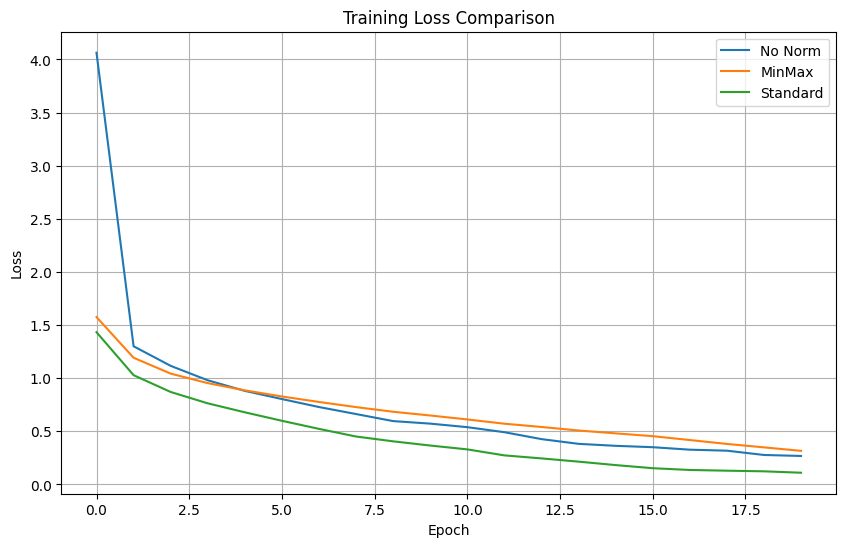

In [14]:
plot_curves(
    histories=[hist_A,hist_B,hist_C],
    labels=['No Norm', 'MinMax', 'Standard'],
    metric='loss',
    title='Training Loss Comparison',
    ylabel='Loss'
)

#### Validation Accuracy Curves

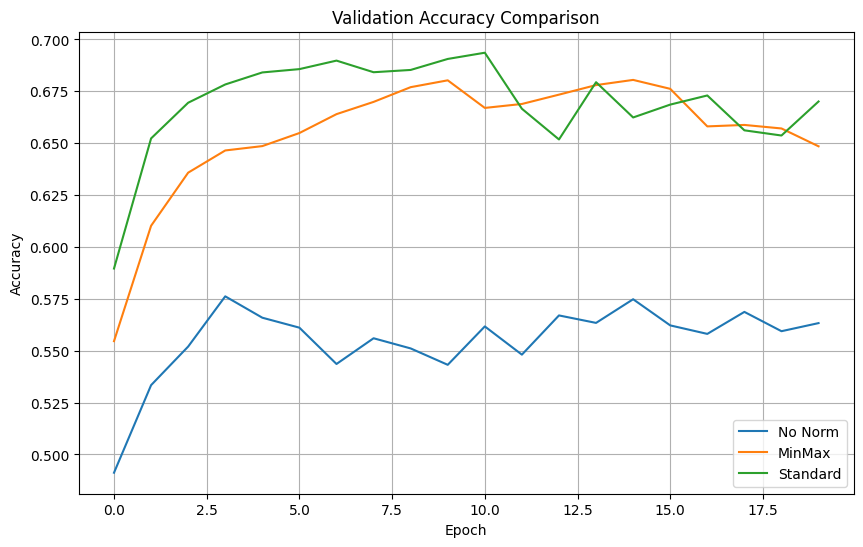

In [15]:
plot_curves(
    histories=[hist_A, hist_B, hist_C],
    labels=['No Norm', 'MinMax', 'Standard'],
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

### Results Table

In [16]:
acc_A_train = hist_A.history['accuracy'][-1]
acc_B_train = hist_B.history['accuracy'][-1]
acc_C_train = hist_C.history['accuracy'][-1]

acc_A_val = hist_A.history['val_accuracy'][-1]
acc_B_val = hist_B.history['val_accuracy'][-1]
acc_C_val = hist_C.history['val_accuracy'][-1]

loss1_A = hist_A.history['loss'][0]
loss1_B = hist_B.history['loss'][0]
loss1_C = hist_C.history['loss'][0]

print("Results Table")
print(f"None         | Train Acc: {acc_A_train:.4f} | Val Acc: {acc_A_val:.4f} | Test Acc: {acc_A:.4f} | Loss@1: {loss1_A:.4f}")
print(f"Min-Max      | Train Acc: {acc_B_train:.4f} | Val Acc: {acc_B_val:.4f} | Test Acc: {acc_B:.4f} | Loss@1: {loss1_B:.4f}")
print(f"Standardized | Train Acc: {acc_C_train:.4f} | Val Acc: {acc_C_val:.4f} | Test Acc: {acc_C:.4f} | Loss@1: {loss1_C:.4f}")

Results Table
None         | Train Acc: 0.9090 | Val Acc: 0.5633 | Test Acc: 0.5619 | Loss@1: 4.0636
Min-Max      | Train Acc: 0.8936 | Val Acc: 0.6485 | Test Acc: 0.6503 | Loss@1: 1.5751
Standardized | Train Acc: 0.9616 | Val Acc: 0.6701 | Test Acc: 0.6671 | Loss@1: 1.4328


## 1B. Data Augmentation

### First Experimnet: Without Augmentation

In [37]:
model_NoAug = BaselineCNN()
compile_model(model_NoAug)

hist_NoAug, acc_NoAug, loss_NoAug, time_NoAug = train_and_evaluate(
    model_NoAug, x_train_C, y_train, x_val_C, y_val, x_test_C, y_test, epochs=40, batch_size=128
)

Test Acc: 0.6648 | Test Loss: 3.3859 | Time:87.6s


### Second Experimnet: With Augmentation

In [38]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
rotation_range=15,
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True,
zoom_range=0.1
)

datagen.fit(x_train_C)

In [39]:
model_Aug = BaselineCNN()
compile_model(model_Aug)

hist_Aug, acc_Aug, loss_Aug, time_Aug = train_and_evaluate(
    model_Aug,
    datagen.flow(x_train_C, to_categorical(y_train,10), batch_size=128),
    y_train,
    x_val_C,
    y_val,
    x_test_C,
    y_test,
    epochs=40,
    batch_size=128,
    aug=True
)

Test Acc: 0.7697 | Test Loss: 0.7155 | Time:891.9s


### Plot the Train and Val Accuracy

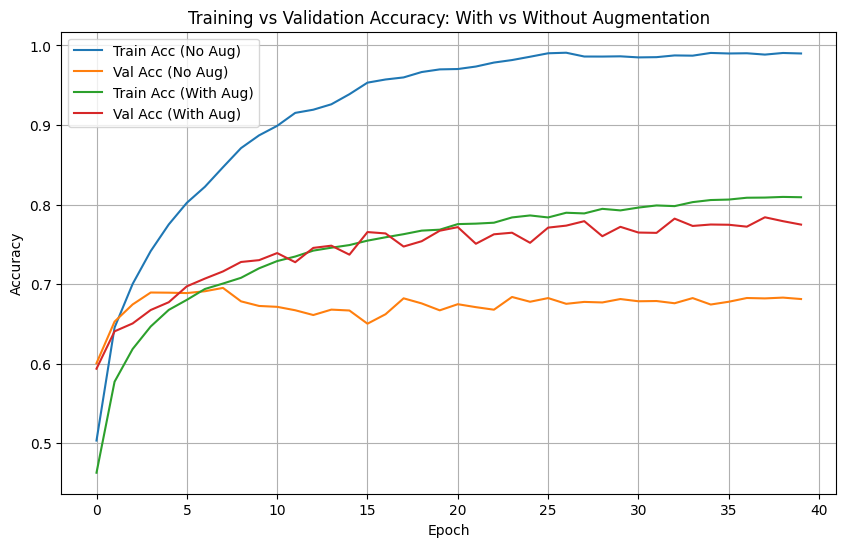

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(hist_NoAug.history['accuracy'],     label='Train Acc (No Aug)')
plt.plot(hist_NoAug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(hist_Aug.history['accuracy'],       label='Train Acc (With Aug)')
plt.plot(hist_Aug.history['val_accuracy'],   label='Val Acc (With Aug)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy: With vs Without Augmentation')
plt.legend()
plt.grid(True)
plt.show()

### Which one overfits less?

In [41]:
acc_Aug_train = hist_Aug.history['accuracy'][-1]
acc_NoAug_train = hist_NoAug.history['accuracy'][-1]

acc_Aug_val = hist_Aug.history['val_accuracy'][-1]
acc_NoAug_val = hist_NoAug.history['val_accuracy'][-1]

gap_NoAug = hist_NoAug.history['accuracy'][-1] - hist_NoAug.history['val_accuracy'][-1]
gap_Aug = hist_Aug.history['accuracy'][-1] - hist_Aug.history['val_accuracy'][-1]


print(f"Without Aug → Train: {hist_NoAug.history['accuracy'][-1]:.4f} | Val: {hist_NoAug.history['val_accuracy'][-1]:.4f} | Gap: {gap_NoAug:.4f}")
print(f"With Aug    → Train: {hist_Aug.history['accuracy'][-1]:.4f} | Val: {hist_Aug.history['val_accuracy'][-1]:.4f} | Gap: {gap_Aug:.4f}")
print(f"\n→ {'With Aug' if gap_Aug < gap_NoAug else 'Without Aug'} overfits less (smaller gap)")

Without Aug → Train: 0.9900 | Val: 0.6812 | Gap: 0.3087
With Aug    → Train: 0.8092 | Val: 0.7748 | Gap: 0.0344

→ With Aug overfits less (smaller gap)


# **4. Task 2: CNN Architecture Experiments**

## 2A.Filter count comparison

### Build Models

In [42]:
def build_model(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        layers.Conv2D(f1, (3,3), activation='relu', padding='same'),
        layers.Conv2D(f2, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(f3, (3,3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

small_model = build_model(8, 8, 16, 16)
medium_model = build_model(32, 32, 64, 64)
large_model = build_model(64, 64, 128, 128)

compile_model(small_model)
compile_model(medium_model)
compile_model(large_model)

### Train the models

In [43]:
hist_s, acc_s, loss_s, time_s = train_and_evaluate(
    small_model,
    x_train_C, y_train,
    x_val_C, y_val,
    x_test_C, y_test
)

hist_m, acc_m, loss_m, time_m = train_and_evaluate(
    medium_model,
    x_train_C, y_train,
    x_val_C, y_val,
    x_test_C, y_test
)

hist_l, acc_l, loss_l, time_l = train_and_evaluate(
    large_model,
    x_train_C, y_train,
    x_val_C, y_val,
    x_test_C, y_test
)

Test Acc: 0.6065 | Test Loss: 2.2778 | Time:43.6s
Test Acc: 0.7061 | Test Loss: 2.2102 | Time:80.1s
Test Acc: 0.7370 | Test Loss: 2.0594 | Time:150.3s


### Models Summary

In [44]:
small_model.summary()
medium_model.summary()
large_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807,800 (3.08 MB)

 Trainable params: 269,266 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,080,416 (27.01 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,720,278 (18.01 MB)

In [45]:
print("{:<10} {:<10} {:<20} {:<20} {:<20} {:<20}".format("Model", "Params", "Train Acc", "Val Acc", "Test Acc", "Time"))

print("{:<10} {:<10} {:<20} {:<20} {:<20} {:<20}".format("Small", small_model.count_params(), hist_s.history['accuracy'][-1], hist_s.history['val_accuracy'][-1], acc_s, time_s))
print("{:<10} {:<10} {:<20} {:<20} {:<20} {:<20}".format("Medium", medium_model.count_params(), hist_m.history['accuracy'][-1], hist_m.history['val_accuracy'][-1], acc_m, time_m))
print("{:<10} {:<10} {:<20} {:<20} {:<20} {:<20}".format("Large", large_model.count_params(), hist_l.history['accuracy'][-1], hist_l.history['val_accuracy'][-1], acc_l, time_l))

Model      Params     Train Acc            Val Acc              Test Acc             Time                
Small      269266     0.9430500268936157   0.612500011920929    0.6065000295639038   43.61942005157471   
Medium     1116970    0.9861500263214111   0.7160000205039978   0.7060999870300293   80.07258176803589   
Large      2360138    0.9845749735832214   0.7433000206947327   0.7369999885559082   150.3265573978424   


### Plot Val Accuracy Curves

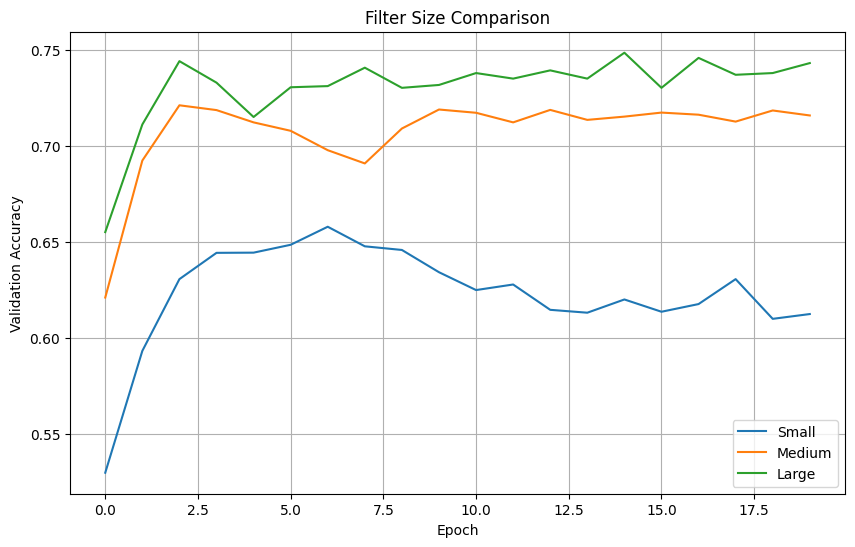

In [46]:
plt.figure(figsize=(10,6))

plt.plot(hist_s.history['val_accuracy'], label='Small')
plt.plot(hist_m.history['val_accuracy'], label='Medium')
plt.plot(hist_l.history['val_accuracy'], label='Large')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Filter Size Comparison')
plt.legend()
plt.grid()
plt.show()

## 2B.Network Depth Comparison

### Build Models

In [47]:
def build_shallow():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_medium():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_deep():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

models_list = [
("Shallow", build_shallow()),
("Medium", build_medium()),
("Deep", build_deep())
]

histories = []
results = []

### Excecute Training and Evaluation for each Model

In [48]:
for name, model in models_list:
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining {name} model...")

    history, acc, loss, t = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test
    )

    histories.append((name, history))
    results.append((name, acc, loss, t))


Training Shallow model...
Test Acc: 0.6921 | Test Loss: 2.2739 | Time:69.0s

Training Medium model...
Test Acc: 0.7257 | Test Loss: 0.7808 | Time:77.2s

Training Deep model...
Test Acc: 0.7267 | Test Loss: 0.8572 | Time:76.9s


### Display Results

In [49]:
import pandas as pd

df = pd.DataFrame(results, columns=["Model", "Accuracy", "Loss", "Time"])
df

,Model,Accuracy,Loss,Time
0,Shallow,0.6921,2.273929,68.958260
1,Medium,0.7257,0.780828,77.181852
2,Deep,0.7267,0.857220,76.924611


### Plot Training and Validation Loss Curves

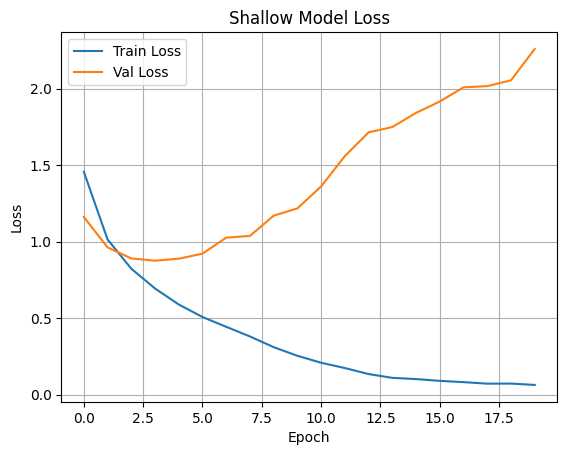

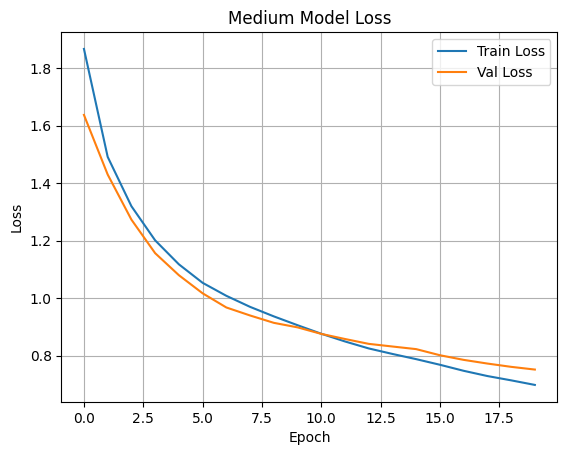

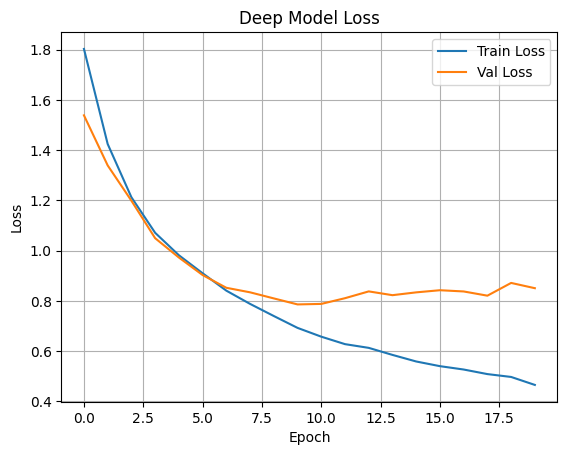

In [50]:
for name, history in histories:
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{name} Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# **5. Task 3: Regularization Experiments**

## 3A.Dropout

### Define a Medium Complexity CNN model with Dropout Layers

In [51]:
def Medium_model_with_dropout(dropout_rate=0.0):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Dropout(dropout_rate),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Dropout(dropout_rate),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),

        layers.Dropout(dropout_rate),

        layers.Dense(10, activation='softmax')
    ])
    return model

### Define different dropout rates to test

In [52]:
configs = {
    "D0": 0.0,
    "D1": 0.25,
    "D2": 0.5
}

results = []
histories = {}

for name, rate in configs.items():
    model = Medium_model_with_dropout(rate)

    compile_model(model)

    print(f"\nTraining {name}...")

    history, acc, loss, t = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=30
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = train_acc - val_acc

    results.append((name, train_acc, val_acc, acc, gap))
    histories[name] = history


Training D0...
Test Acc: 0.7252 | Test Loss: 2.3631 | Time:116.0s

Training D1...
Test Acc: 0.7697 | Test Loss: 0.9777 | Time:122.8s

Training D2...
Test Acc: 0.7930 | Test Loss: 0.6140 | Time:122.6s


### Display results


In [53]:
df = pd.DataFrame(results, columns=[
    "Model", "Train Acc", "Val Acc", "Test Acc", "Overfit Gap"
])
df

,Model,Train Acc,Val Acc,Test Acc,Overfit Gap
0,D0,0.98835,0.7195,0.7252,0.26885
1,D1,0.93645,0.7738,0.7697,0.16265
2,D2,0.78920,0.8023,0.7930,-0.01310


### Plot validation accuracy curves


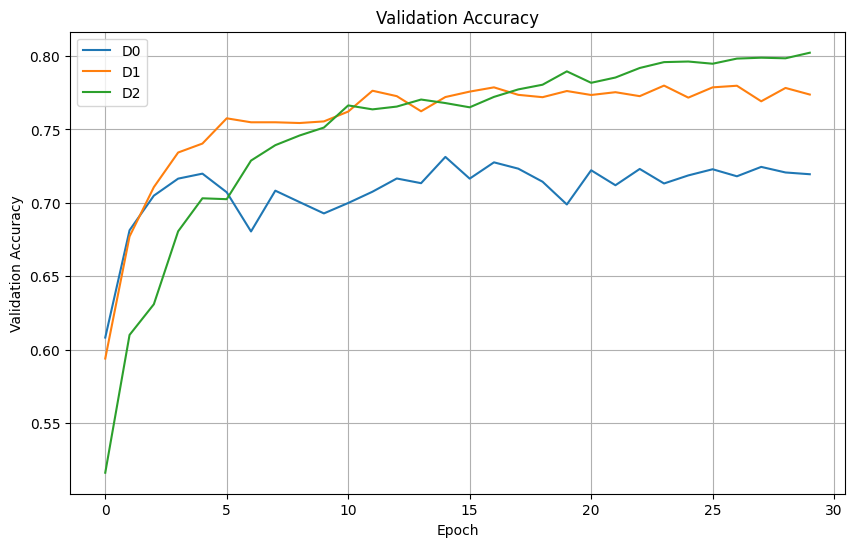

In [54]:
plot_curves(histories=histories.values(), labels=histories.keys(), title='Validation Accuracy', ylabel='Validation Accuracy', metric='val_accuracy')

### Plot training accuracy curves

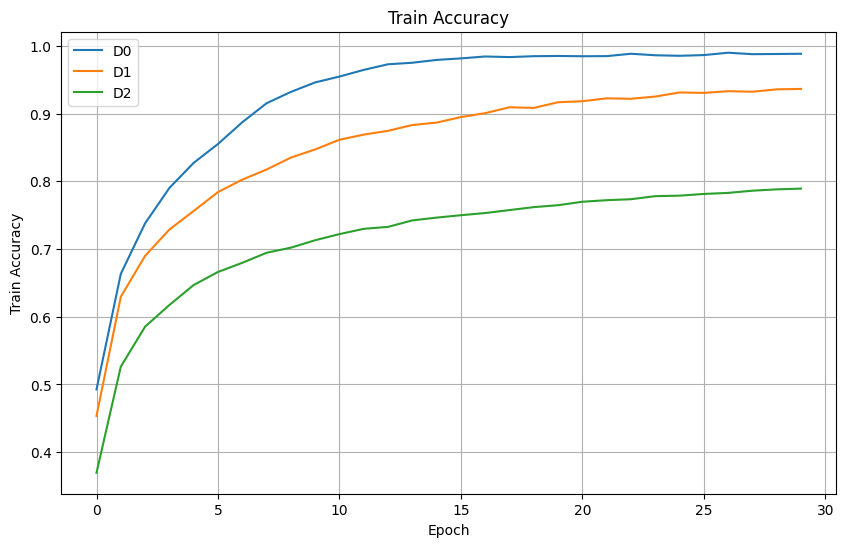

In [55]:
plot_curves(histories.values(), labels=histories.keys(), title='Train Accuracy', ylabel='Train Accuracy', metric='accuracy')


## 3B. EarlyStopping

### Define Early Stopping

In [56]:
es2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

es3 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

### Train in different Early Stoping

In [57]:
experiments = {
    "ES0": None,
    "ES2": es2,
    "ES3": es3
}

results_es = []
hist_es = {}


experiments = {
    "ES0": None,
    "ES2": es2,
    "ES3": es3
}

results_es = []
hist_es = {}

for name, cb in experiments.items():
    model = Medium_model_with_dropout(0.0)

    compile_model(model)

    print(f"\nTraining {name}...")

    history = model.fit(
        x_train_C, to_categorical(y_train,10),
        validation_data=(x_val, to_categorical(y_val,10)),
        epochs=50,
        batch_size=128,
        callbacks=[cb] if cb else [],
        verbose=0
    )

    stopped_epoch = len(history.history['loss'])
    best_val_loss = min(history.history['val_loss'])

    test_loss, test_acc = model.evaluate(
        x_test_C, to_categorical(y_test,10), verbose=0
    )

    results_es.append((name, stopped_epoch, best_val_loss, test_acc))
    hist_es[name] = history


Training ES0...

Training ES2...

Training ES3...


### Results Table

In [58]:
df_es = pd.DataFrame(results_es, columns=[
    "Experiment", "Stopped Epoch", "Best Val Loss", "Test Acc"
])
df_es

,Experiment,Stopped Epoch,Best Val Loss,Test Acc
0,ES0,50,46.704914,0.7080
1,ES2,9,42.057476,0.7054
2,ES3,14,37.380074,0.7251


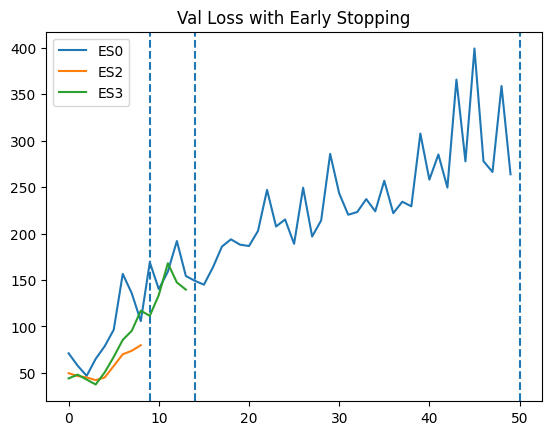

In [59]:
plt.figure()

for name, h in hist_es.items():
    plt.plot(h.history['val_loss'], label=name)

    stop_epoch = len(h.history['val_loss'])
    plt.axvline(stop_epoch, linestyle='--')

plt.legend()
plt.title("Val Loss with Early Stopping")
plt.show()

# **6. Task 4: Optimizer Comparison**

## 4A. Same Learning Rate

In [60]:
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
}

### Train with all 5 optimizers at

In [61]:
opt_results = {}
for opt_name, optimizer in optimizers.items():
    print(f"\n{'='*50}")
    print(f"  Training with optimizer: {opt_name}")
    print(f"{'='*50}\n")

    model = build_model(32, 32, 64, 64)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=30
    )

    opt_results[opt_name] = history



  Training with optimizer: SGD

Test Acc: 0.5122 | Test Loss: 1.3723 | Time:112.3s

  Training with optimizer: Momentum

Test Acc: 0.6731 | Test Loss: 1.1515 | Time:114.5s

  Training with optimizer: AdaGrad

Test Acc: 0.5808 | Test Loss: 1.1967 | Time:114.2s

  Training with optimizer: RMSProp

Test Acc: 0.7256 | Test Loss: 3.5128 | Time:113.6s

  Training with optimizer: Adam

Test Acc: 0.7138 | Test Loss: 2.5596 | Time:115.3s


In [62]:
print("{:<10} {:<20} {:<20} {:<20} {:<20}".format("Optimizer", "Train Loss", "Val Loss", "Test Acc", "Time"))
for opt_name, (history, test_acc, test_loss, elapsed) in opt_results.items():
    print("{:<10} {:<20} {:<20} {:<20} {:<20}".format(opt_name, f"{history.history['loss'][-1]:.4f}", f"{history.history['val_loss'][-1]:.4f}", f"{test_acc:.4f}", f"{elapsed:.1f}s"))

Optimizer  Train Loss           Val Loss             Test Acc             Time                
SGD        1.3305               1.3849               0.5122               112.3s              
Momentum   0.3816               1.1456               0.6731               114.5s              
AdaGrad    1.1203               1.2132               0.5808               114.2s              
RMSProp    0.0353               3.4217               0.7256               113.6s              
Adam       0.0302               2.4221               0.7138               115.3s              


### Plot: all 5 val accuracy curves on one graph

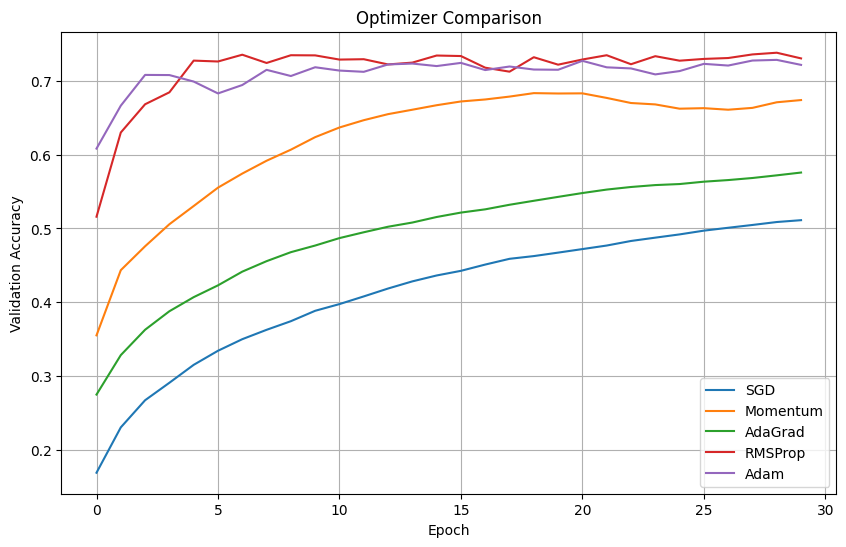

In [63]:
plot_curves([h for h, _, _, _ in opt_results.values()], list(opt_results.keys()), title="Optimizer Comparison", ylabel="Validation Accuracy")

### Plot: all 5 training loss curves on one graph

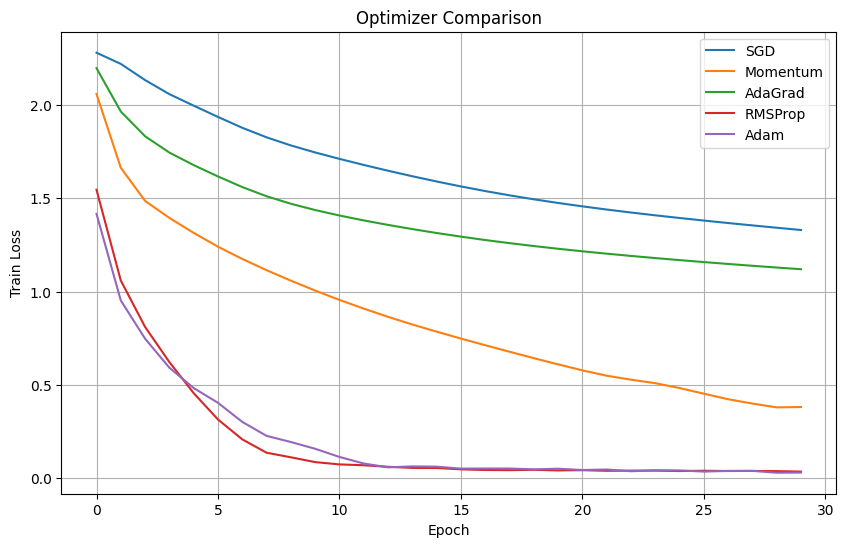

In [64]:
plot_curves([h for h, _, _, _ in opt_results.values()], list(opt_results.keys()), title="Optimizer Comparison", ylabel="Train Loss", metric='loss')

### Which optimizer converges fastest (reaches val_acc > 0.65 first)?

> Adam Optimizer

## 4B. Learning Rate Sensitivity — Adam

### Train with different learning rates

In [65]:
LRs = [0.0001, 0.001, 0.01]
lr_results = {}
for lr in LRs:
    print(f"\n{'='*50}")
    print(f"  Training with learning rate: {lr}")
    print(f"{'='*50}\n")

    model = build_model(32, 32, 64, 64)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=30
    )

    lr_results[lr] = history


  Training with learning rate: 0.0001

Test Acc: 0.6537 | Test Loss: 1.3831 | Time:117.0s

  Training with learning rate: 0.001

Test Acc: 0.7187 | Test Loss: 2.5564 | Time:115.3s

  Training with learning rate: 0.01

Test Acc: 0.4794 | Test Loss: 1.6312 | Time:113.1s


In [66]:
print("{:<10} {:<20} {:<20} {:<20}".format("LR", "Train Loss", "Val Loss", "Test Acc"))
for lr, (history, test_acc, test_loss, elapsed) in lr_results.items():
    print("{:<10} {:<20} {:<20} {:<20}".format(lr, f"{history.history['loss'][-1]:.4f}", f"{history.history['val_loss'][-1]:.4f}", f"{test_acc:.4f}", f"{elapsed:.1f}s"))

LR         Train Loss           Val Loss             Test Acc            
0.0001     0.2644               1.3511               0.6537              
0.001      0.0368               2.5888               0.7187              
0.01       0.9569               1.6563               0.4794              


### Plot: all 3 training loss curves on one graph

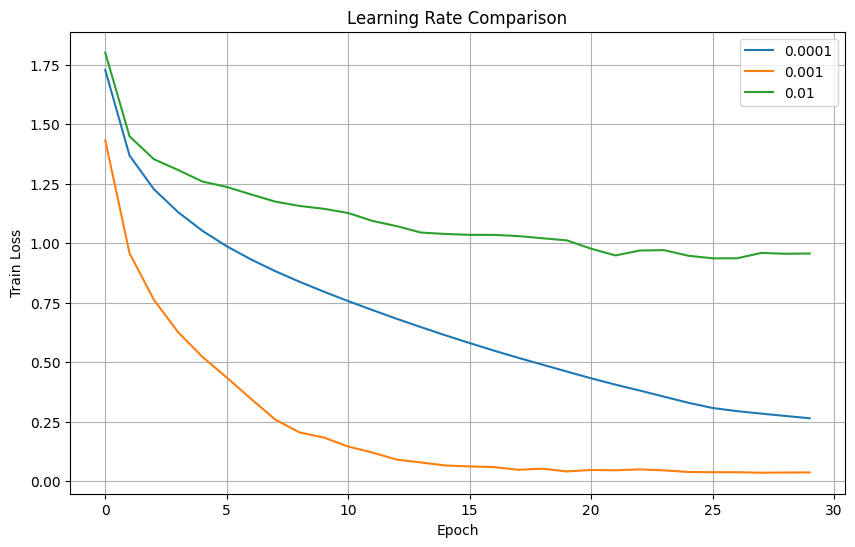

In [67]:
plot_curves([h for h, _, _, _ in lr_results.values()], list(lr_results.keys()), title="Learning Rate Comparison", ylabel="Train Loss", metric='loss')

### Plot: all 3 val accuracy curves on one graph

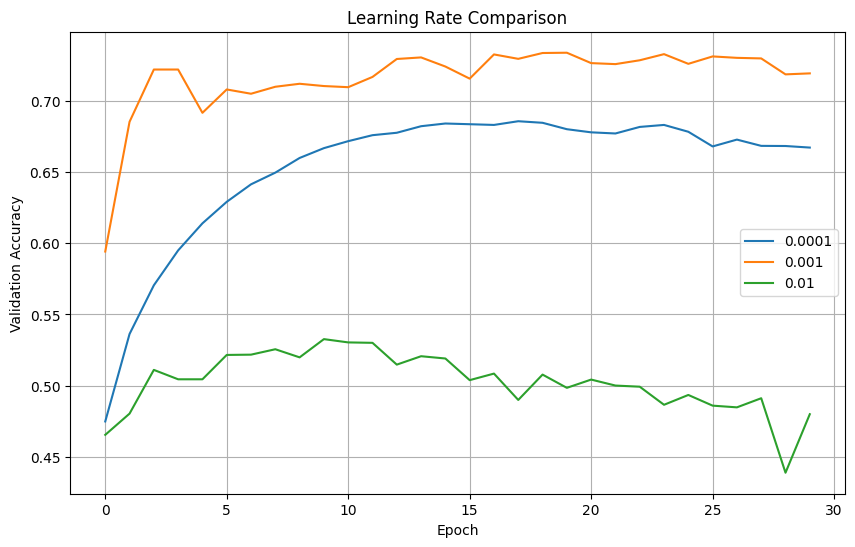

In [68]:
plot_curves([h for h, _, _, _ in lr_results.values()], list(lr_results.keys()), title="Learning Rate Comparison", ylabel="Validation Accuracy")

### Which learning rate is too slow? Which is unstable? Which is the best?

> Slow: 0.0001

> Unstable: 0.01

> Best: 0.001

# **7. Task 5: Performance Evaluation**

## 5A. Best Model Selection & Evaluation

### which settings you chose and why

| Component           | Choice                          | Reason                                                           |
| ------------------- | ------------------------------- | ---------------------------------------------------------------- |
| Preprocessing       | Standardization                 | Provided better stability and faster convergence during training |
| Data Augmentation   | Enabled                         | Reduced overfitting and improved generalization                  |
| Architecture        | Medium-Deep CNN                 | Balanced model complexity and performance                        |
| Batch Normalization | Used after Conv layers          | Improved training stability and convergence speed                |
| Dropout             | 0.25 (Conv blocks), 0.5 (Dense) | Reduced overfitting while maintaining performance                |
| Optimizer           | Adam                            | Achieved the fastest and most stable convergence                 |
| Learning Rate       | 0.001                           | Provided the best balance between speed and stability            |
| Early Stopping      | Patience = 7                    | Prevented over-training and preserved best weights               |


### Build Model

In [97]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

### Compile the Model

In [70]:
compile_model(model)

### Early Stoping

In [71]:
es2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

In [72]:
history, test_acc, test_loss, t = train_and_evaluate(
        model,
        datagen.flow(x_train_C, to_categorical(y_train,10), batch_size=128), y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=50,
        batch_size=128,
        aug=True,
        extra_callbacks=[es2]
    )

print(f"Final Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {t:.1f}s")

Test Acc: 0.8764 | Test Loss: 0.3809 | Time:1008.9s
Final Test Accuracy: 0.8764 | Test Loss: 0.3809 | Time: 1008.9s


In [73]:
print(f"Early Stopping @ Epoch: {len(history.history['loss'])}")
print(f"Train Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")

Early Stopping @ Epoch: 41
Train Accuracy: 0.8978
Val Accuracy: 0.8855


### The Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


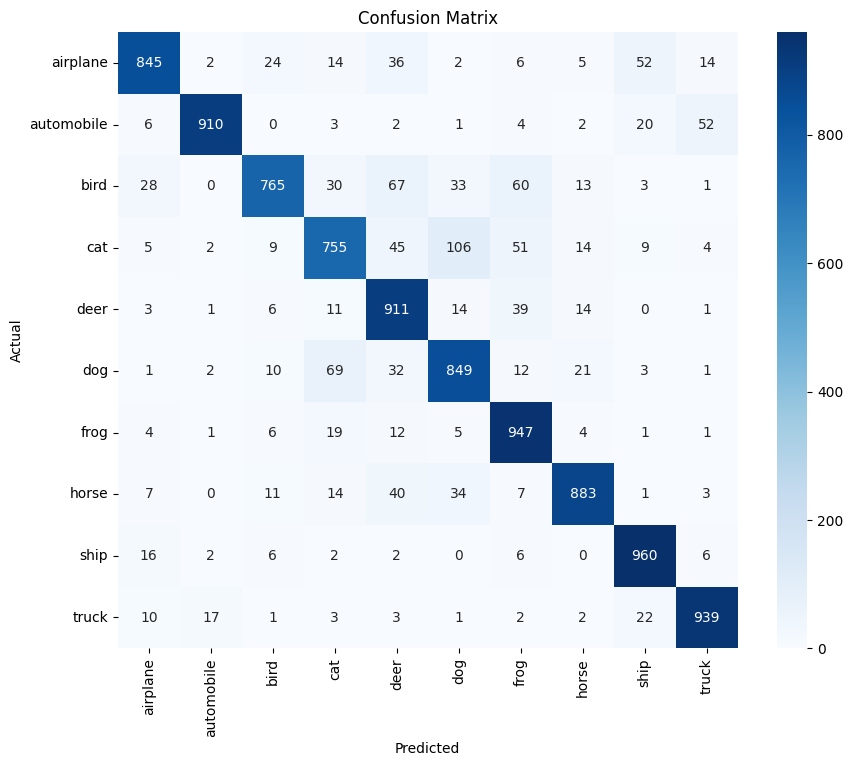

              precision    recall  f1-score   support

    airplane       0.91      0.84      0.88      1000
  automobile       0.97      0.91      0.94      1000
        bird       0.91      0.77      0.83      1000
         cat       0.82      0.76      0.79      1000
        deer       0.79      0.91      0.85      1000
         dog       0.81      0.85      0.83      1000
        frog       0.84      0.95      0.89      1000
       horse       0.92      0.88      0.90      1000
        ship       0.90      0.96      0.93      1000
       truck       0.92      0.94      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [74]:
y_pred = np.argmax(model.predict(x_test_C), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

## 5B. Error Analysis

### The 3 Worst-Performing Classes

In [75]:
report = classification_report(y_test.flatten(), y_pred,
                                target_names=CLASS_NAMES,
                                output_dict=True)

recalls = {cls: report[cls]['recall'] for cls in CLASS_NAMES}
worst_3 = sorted(recalls, key=recalls.get)[:3]

print("Worst 3 classes by recall:")
for cls in worst_3:
    print(f"  {cls}: recall = {recalls[cls]:.4f}")

Worst 3 classes by recall:
  cat: recall = 0.7550
  bird: recall = 0.7650
  airplane: recall = 0.8450


### Display 5 Misclassified Images

In [76]:
misclassified_idx = np.where(y_pred != y_test.flatten())[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")
def show_misclassified(true_class_name, n=5):
    true_class_idx = CLASS_NAMES.index(true_class_name)
    idx = [i for i in misclassified_idx if y_test.flatten()[i] == true_class_idx][:n]

    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for ax, i in zip(axes, idx):
        ax.imshow(x_test[i].astype('uint8'))
        ax.set_title(f"True: {CLASS_NAMES[y_test.flatten()[i]]}\nPred: {CLASS_NAMES[y_pred[i]]}", fontsize=9)
        ax.axis('off')
    plt.suptitle(f"Misclassified '{true_class_name}'", fontsize=12)
    plt.tight_layout()
    plt.show()

Total misclassified: 1236 / 10000


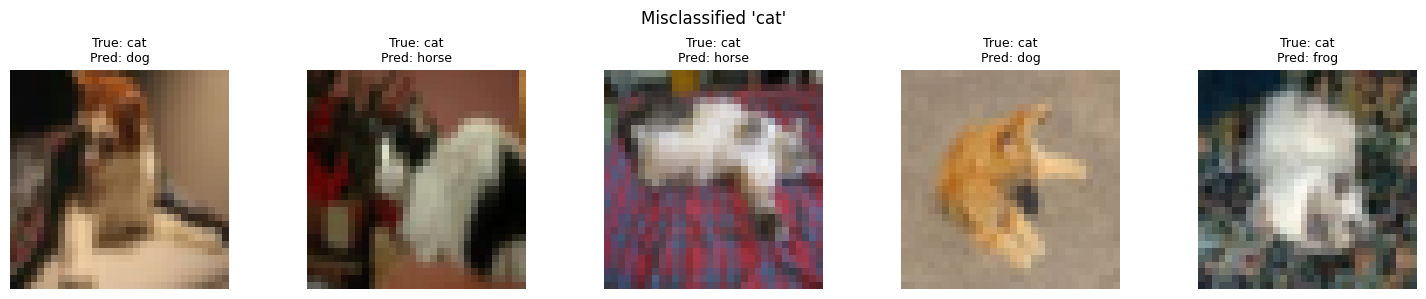

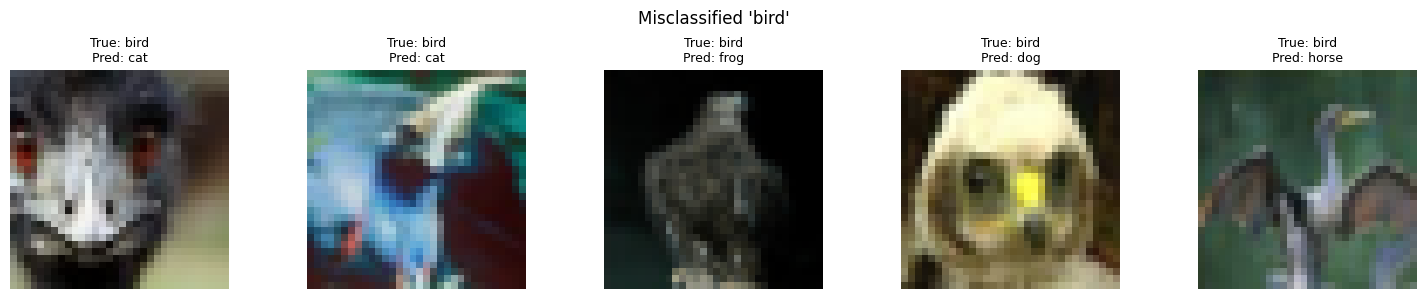

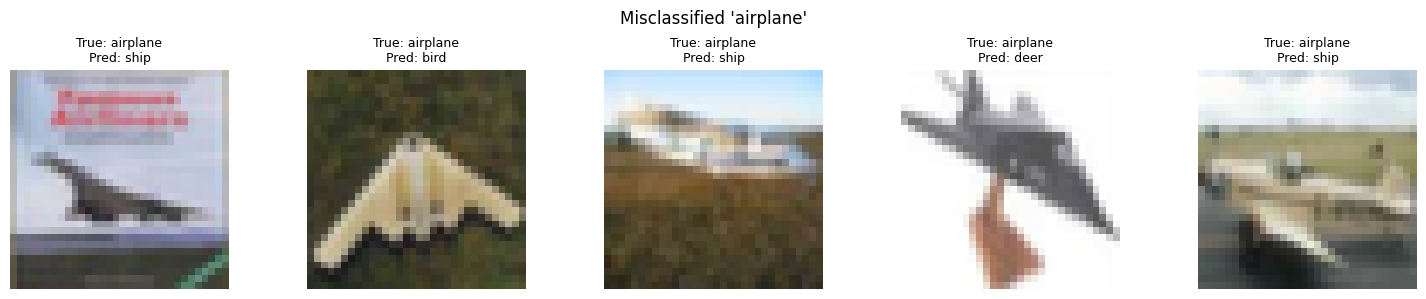

In [77]:
for cls in worst_3:
    show_misclassified(cls)

### Top 3 Most Confused Class Pairs

In [78]:
cm = confusion_matrix(y_test.flatten(), y_pred)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            confused_pairs.append((cm_no_diag[i, j], i, j))

confused_pairs.sort(reverse=True)

seen = set()
top_3_pairs = []
for count, i, j in confused_pairs:
    pair = tuple(sorted([i, j]))
    if pair not in seen:
        seen.add(pair)
        top_3_pairs.append((i, j))
    if len(top_3_pairs) == 3:
        break

print("Top 3 most confused pairs:")
for i, j in top_3_pairs:
    print(f"  {CLASS_NAMES[i]} ↔ {CLASS_NAMES[j]}: "
          f"{CLASS_NAMES[i]}→{CLASS_NAMES[j]}: {cm[i,j]}, "
          f"{CLASS_NAMES[j]}→{CLASS_NAMES[i]}: {cm[j,i]}")

Top 3 most confused pairs:
  cat ↔ dog: cat→dog: 106, dog→cat: 69
  bird ↔ deer: bird→deer: 67, deer→bird: 6
  bird ↔ frog: bird→frog: 60, frog→bird: 6


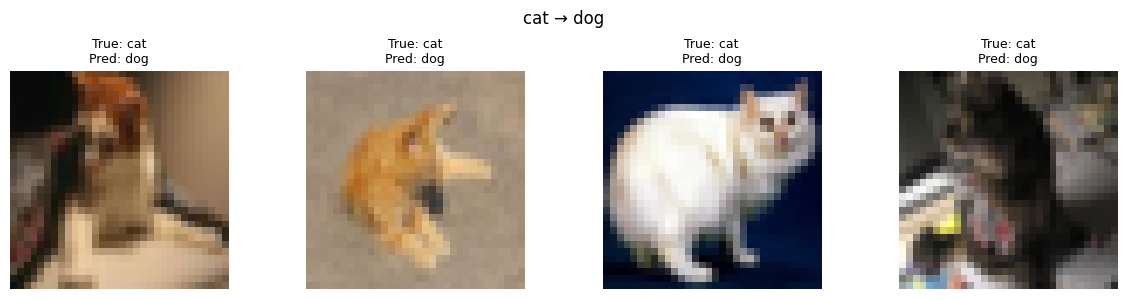

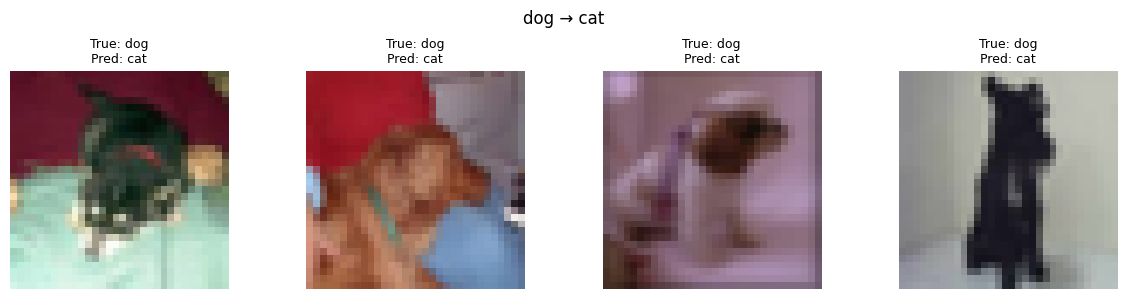

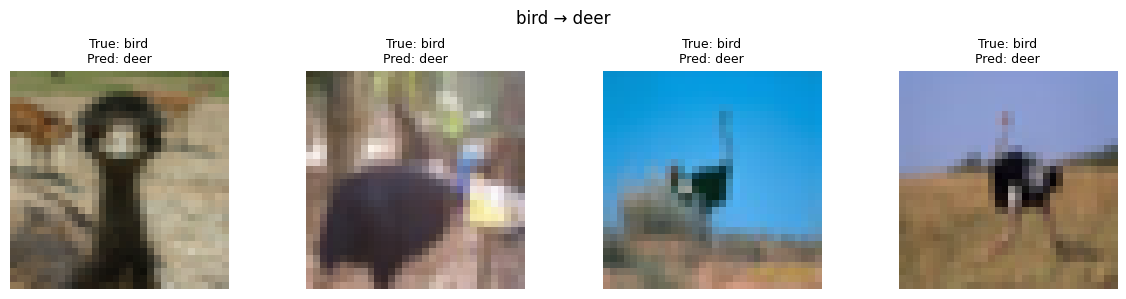

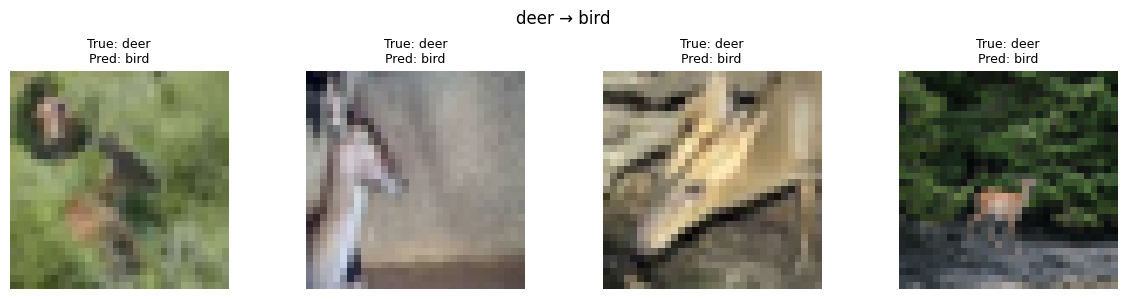

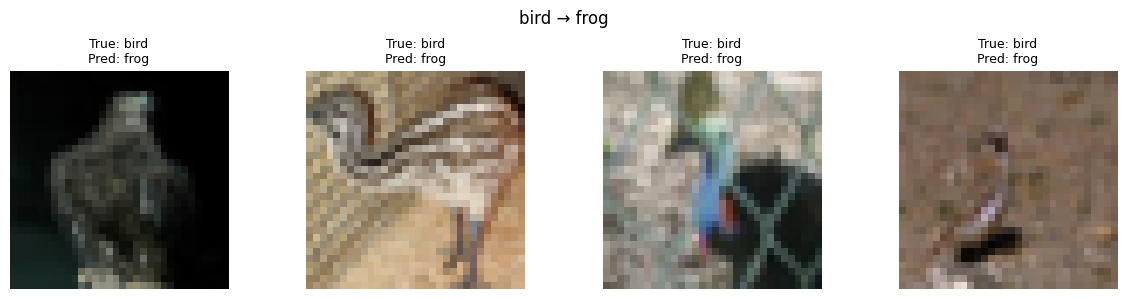

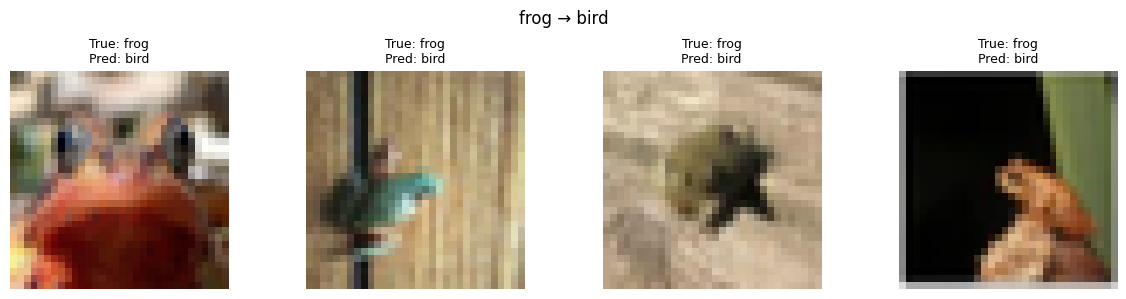

In [79]:
def show_confused_pair(true_cls, pred_cls, n=4):
    true_idx = CLASS_NAMES.index(true_cls)
    pred_idx = CLASS_NAMES.index(pred_cls)
    idx = [i for i in misclassified_idx
           if y_test.flatten()[i] == true_idx and y_pred[i] == pred_idx][:n]

    if not idx:
        print(f"No examples found: {true_cls} → {pred_cls}")
        return

    fig, axes = plt.subplots(1, n, figsize=(12, 3))
    for ax, i in zip(axes, idx):
        ax.imshow(x_test[i].astype('uint8'))
        ax.set_title(f"True: {true_cls}\nPred: {pred_cls}", fontsize=9)
        ax.axis('off')
    plt.suptitle(f"{true_cls} → {pred_cls}", fontsize=12)
    plt.tight_layout()
    plt.show()

for i, j in top_3_pairs:
    show_confused_pair(CLASS_NAMES[i], CLASS_NAMES[j])
    show_confused_pair(CLASS_NAMES[j], CLASS_NAMES[i])

### Why these classes are hard to distinguish at 32×32:

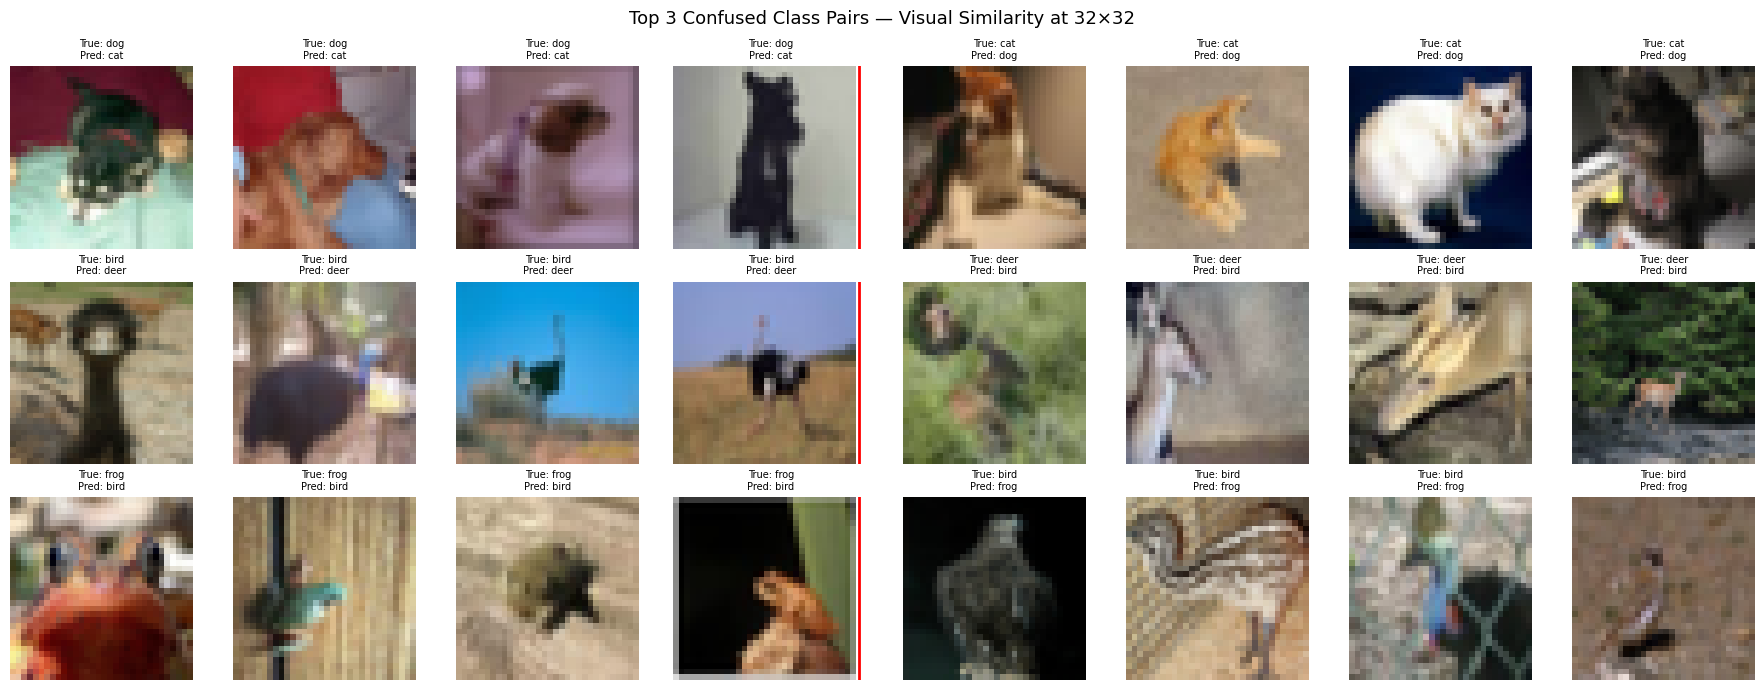

In [98]:
worst_3 = ['cat', 'airplane', 'bird']

top_3_pairs = [('dog', 'cat'), ('bird', 'deer'), ('frog', 'bird')]

fig, axes = plt.subplots(3, 8, figsize=(18, 7))

for row, (cls_a, cls_b) in enumerate(top_3_pairs):
    idx_a = CLASS_NAMES.index(cls_a)
    idx_b = CLASS_NAMES.index(cls_b)

    wrong_a = [i for i in misclassified_idx
               if y_test.flatten()[i] == idx_a and y_pred[i] == idx_b][:4]

    wrong_b = [i for i in misclassified_idx
               if y_test.flatten()[i] == idx_b and y_pred[i] == idx_a][:4]

    for col, i in enumerate(wrong_a):
        axes[row, col].imshow(x_test[i].astype('uint8'))
        axes[row, col].set_title(f"True: {cls_a}\nPred: {cls_b}", fontsize=7)
        axes[row, col].axis('off')

    for col, i in enumerate(wrong_b):
        axes[row, col + 4].imshow(x_test[i].astype('uint8'))
        axes[row, col + 4].set_title(f"True: {cls_b}\nPred: {cls_a}", fontsize=7)
        axes[row, col + 4].axis('off')

    axes[row, 3].axvline(x=32, color='red', linewidth=2)

for row, (cls_a, cls_b) in enumerate(top_3_pairs):
    axes[row, 0].set_ylabel(f"{cls_a} ↔ {cls_b}", fontsize=10, fontweight='bold')

plt.suptitle("Top 3 Confused Class Pairs — Visual Similarity at 32×32", fontsize=13)
plt.tight_layout()
plt.show()

1. cat ↔ dog:
    Both are four-legged mammals with similar body shapes
    Similar fur textures and colors
    At low resolution, facial details (ears, snout, eyes) become blurry
    Many CIFAR-10 images have similar poses/backgrounds (e.g., animals on grass)

2. bird ↔ deer:
    At 32×32, fine structural differences disappear
    Birds in the dataset are sometimes:
    far away
    partially occluded
    This makes them look like small blobs or shapes, similar to distant deer

3. bird ↔ frog:
    Both can appear as small objects in natural scenes (grass, water)
    Colors like green/brown overlap
    Low resolution removes key features:
        wings (bird)
        body shape differences

# **8. Task 6: Transfer Learning**

In [81]:
x_train_resized = tf.image.resize(x_train_C, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_C, (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_C, (48, 48)).numpy()

print(x_train_resized.shape)
print(x_val_resized.shape)
print(x_test_resized.shape)

(40000, 48, 48, 3)
(10000, 48, 48, 3)
(10000, 48, 48, 3)


## Model 1: From Scratch

In [82]:
def build_medium_cnn_48():
    model = models.Sequential([
        layers.Input(shape=(48, 48, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model1 = build_medium_cnn_48()
compile_model(model1)

In [83]:
hist1, acc1, loss1, time1 = train_and_evaluate(
    model1,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test
)

Test Acc: 0.6800 | Test Loss: 2.8493 | Time:152.1s


## Model 2 — Feature Extraction (Frozen VGG16)

In [84]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model2 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [85]:
for layer in base_model2.layers:
    layer.trainable = False

In [86]:
def sequential_model(model):
  return models.Sequential([
    model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [87]:
model2 = sequential_model(base_model2)

compile_model(model2)

In [88]:
model2.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_30 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [89]:
hist2, acc2, loss2, time2 = train_and_evaluate(
    model2,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test
)

Test Acc: 0.6949 | Test Loss: 0.9051 | Time:400.7s


## Model 3 — Fine-Tuning (Partial Unfreeze)

In [108]:
base_model3 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)

In [109]:
for layer in base_model3.layers:
    layer.trainable = False

In [110]:
for layer in base_model3.layers[-4:]:
    layer.trainable = True

In [111]:
model3 = sequential_model(base_model3)

compile_model(model3, lr=1e-5)

In [112]:
model3.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_33 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [113]:
hist3, acc3, loss3, time3 = train_and_evaluate(
    model3,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test
)

Test Acc: 0.8256 | Test Loss: 0.5533 | Time:454.7s


## Model 4 — Fine-Tuning (Higher Learning Rate)

In [101]:
base_model4 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)

In [102]:
for layer in base_model4.layers:
    layer.trainable = False

In [104]:
for layer in base_model4.layers[-4:]:
    layer.trainable = True

In [105]:
model4 = sequential_model(base_model4)

compile_model(model4)

In [106]:
hist4, acc4, loss4, time4 = train_and_evaluate(
    model4,
    x_train_resized, y_train,
    x_val_resized, y_val,
    x_test_resized, y_test
)

Test Acc: 0.8227 | Test Loss: 1.5227 | Time:449.7s


## Results Table

In [114]:
results = pd.DataFrame({
    "Model": ["From Scratch", "Feature Extraction", "Fine-Tune lr=1e-5", "Fine-Tune lr=1e-3"],
    "Trainable Params": [
        model1.count_params(),
        sum([tf.keras.backend.count_params(w) for w in model2.trainable_weights]),
        sum([tf.keras.backend.count_params(w) for w in model3.trainable_weights]),
        sum([tf.keras.backend.count_params(w) for w in model4.trainable_weights])
    ],
    "Non-Trainable Params": [
        0,
        sum([tf.keras.backend.count_params(w) for w in model2.non_trainable_weights]),
        sum([tf.keras.backend.count_params(w) for w in model3.non_trainable_weights]),
        sum([tf.keras.backend.count_params(w) for w in model4.non_trainable_weights])
    ],
    "Test Accuracy": [acc1, acc2, acc3, acc4],
    "Time (s)": [time1, time2, time3, time4]
})

results

,Model,Trainable Params,Non-Trainable Params,Test Accuracy,Time (s)
0,From Scratch,2427690,0,0.6800,152.135052
1,Feature Extraction,133898,14714688,0.6949,400.733678
2,Fine-Tune lr=1e-5,7213322,7635264,0.8256,454.705248
3,Fine-Tune lr=1e-3,7213322,7635264,0.8227,449.737942


## Plot: val accuracy curves — all 4 models on one graph

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(hist1.history['val_accuracy'], label='From Scratch')
plt.plot(hist2.history['val_accuracy'], label='Feature Extraction')
plt.plot(hist3.history['val_accuracy'], label='Fine-tune lr=1e-5')
plt.plot(hist4.history['val_accuracy'], label='Fine-tune lr=1e-3')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid()
plt.show()

## Plot: val loss curves — all 4 models on one graph

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(hist1.history['val_loss'], label='From Scratch')
plt.plot(hist2.history['val_loss'], label='Feature Extraction')
plt.plot(hist3.history['val_loss'], label='Fine-tune lr=1e-5')
plt.plot(hist4.history['val_loss'], label='Fine-tune lr=1e-3')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid()
plt.show()

## Why does Model 4 (lr=0.001) perform differently from Model 3 (lr=1e-5)?


> Model 4 performs worse because it uses a high learning rate (0.001), which causes large updates that destroy the pre-trained weights. Model 3 uses a small learning rate (1e-5), allowing gradual updates and better performance.

## Does transfer learning outperform training from scratch on CIFAR-10? Why or why not?

> Yes, transfer learning outperforms training from scratch. The fine-tuned model achieved higher accuracy (0.82) compared to from scratch (0.69) because it uses pre-learned features from ImageNet.

# 9. Team Members

| Member Name | Tasks Completed | Specific Contribution | Time Spent | 
| ----------- | --------------- | --------------------- | ---------- |
| Merehan Ibrahim (ID: 20230435)| Task 1A, Task 6 | • Implemented all 3 normalization experiments (No norm, Min-Max, Standardization) • Plotted training loss and validation accuracy curves for Task 1A • Filled results table for Task 1A • Built all 4 transfer learning models (From Scratch, Feature Extraction, Fine-Tune lr=1e-5, Fine-Tune lr=1e-3) • Printed model summaries for Models 2 and 3 • Filled transfer learning results table • Plotted val accuracy and val loss curves for all 4 models • Wrote analysis for questions 48 and 49 | ~10 hours
| Yasmeen Abd El-Hamed (ID: 20231204) | Task 2A, Task 2C, Task 3A, Task 3B | • Built CNN models with different filter counts (Small, Medium, Large) using a parameterized function • Printed model summaries and noted parameter counts • Plotted val accuracy curves for Task 2A • Built depth comparison models (Shallow, Medium, Deep) • Plotted training and val loss for each depth model • Wrote analysis for Task 2C • Built all 3 dropout models (D0, D1, D2) and computed overfitting gap • Plotted val and train accuracy curves for Task 3A • Ran all 3 early stopping experiments (ES0, ES2, ES3) • Plotted val loss with stopping point markers for Task 3B • Wrote analysis for Tasks 3A and 3B | ~12 hours |
| Seif El-Deen Amr (ID: 20230184) | Task 1B, Task 4A, Task 4B, Task 5A, Task 5B | Implemented data augmentation and trained with/without augmentation • Plotted 4-curve accuracy graph and reported overfitting gap for Task 1B • Ran all 5 optimizer experiments in a loop and created comparison plots for Task 4A • Ran all 3 learning rate experiments and created comparison plots for Task 4B • Wrote analysis for Tasks 4A and 4B • Selected best model combination and justified all settings • Trained best model with early stopping and data augmentation achieving 87% test accuracy • Generated confusion matrix and classification report • Performed full error analysis including worst 3 classes, misclassified images, and top 3 confused pairs | ~13 hours  